# On frangi

`skimage.filters.frangi` has five separable defects. Four are in the filter,
one is inherited from `hessian_matrix` and is fixed in `on_hessian.md`. This
notebook takes them one at a time: what the filter is supposed to do, what it
does, the smallest example that shows the difference, and a runnable repair.

| | defect | consequence | status upstream |
| --- | --- | --- | --- |
| D1 | the wrong-sign rejection is defeated when $\lambda_1 = 0$ | `black_ridges` has **no effect** on an ideal ridge | residue of [#6436](https://github.com/scikit-image/scikit-image/issues/6436), not reported |
| D2 | no scale normalisation on the Hessian | ideal ridges never select their width; non-trivial vesselness collapses to the finest σ | [#7711](https://github.com/scikit-image/scikit-image/issues/7711), open |
| D3 | `gamma=None` is resolved *inside* the σ loop | output depends on the **order** of `sigmas` | not reported |
| D4 | `gamma=None` is a whole-image statistic | one distant pixel changes the answer | noted in [#6436](https://github.com/scikit-image/scikit-image/issues/6436) |
| D5 | border error from the two-pass Hessian | a bright rim, large relative to the output range | `on_hessian.md`, fixes A and C |
| D6 | `alpha` is documented but inert in 2-D | a parameter that does nothing, silently | noted in [#6436](https://github.com/scikit-image/scikit-image/issues/6436) |

D3 and D4 are the subject of `on_meijering.md`'s sibling argument: both filters
take a maximum over scales while letting a whole-image number into the loop.
D6 is a documentation defect and is dealt with in one paragraph.

Coordinates are in array order throughout. All sections assume 2-D unless they
say otherwise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import permutations

In [2]:
import skimage as ski
from skimage.filters import frangi, sato, meijering
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
import scipy.ndimage as ndi

In [3]:
# Slots 1 to 3 of the reference categorical palette, validated all-pairs;
# same palette as `on_meijering.md` and `on_hessian.md`.
C_ONE, C_TWO, C_THREE = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd5"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f7f7f4", C_ONE])

plt.rcParams.update(
    {"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9,
     "axes.titlecolor": MUTED, "figure.facecolor": "white"}
)


def bare(ax, title=None):
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if title:
        ax.set_title(title)
    return ax


def recede(ax, title=None):
    ax.tick_params(labelsize=8, colors=MUTED)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    if title:
        ax.set_title(title)
    return ax

## 1. What `frangi` computes

Frangi's filter asks, at every pixel and every scale, whether the local second
order structure looks like a tube. It smooths the image with a Gaussian of
width σ, takes the matrix of second derivatives — the Hessian $H$ — and looks at
its eigenvalues $\lambda_1, \lambda_2$, ordered so that
$|\lambda_1| \le |\lambda_2|$.

For a bright line on a dark background the cross-section curves sharply
downward and the along-line direction is flat, so
$\lambda_2 \ll 0$ and $\lambda_1 \approx 0$. For a blob both curve, so
$\lambda_1 \approx \lambda_2$. [Frangi *et al.*
(1998)](https://doi.org/10.1007/BFb0056195) turn that into two dimensionless
numbers and one absolute one:

$$
R_b = \frac{|\lambda_1|}{|\lambda_2|}, \qquad
S = \|H\|_F = \sqrt{\lambda_1^2 + \lambda_2^2},
$$

and combine them as

$$
\mathcal{V}
= \underbrace{\exp\!\left(-\frac{R_b^{2}}{2\beta^{2}}\right)}_{\text{blobness}}
\cdot
\underbrace{\left(1 - \exp\!\left(-\frac{S^{2}}{2\gamma^{2}}\right)\right)}_{\text{structuredness}} ,
$$

with the convention that $\mathcal{V} = 0$ wherever an eigenvalue has the wrong
sign for the polarity being sought. The final answer is the maximum of
$\mathcal{V}$ over a list of scales.

Three things about that expression drive everything below.

- $R_b$ is a **ratio**. Scaling the Hessian leaves it alone, so blobness carries
  no information about σ.
- $S$ is the only **absolute** quantity, and γ is its reference level. γ is
  therefore the filter's sole contrast threshold. Frangi sets it, in their
  words, to "half the value of the maximum Hessian norm".
- In 2-D the plate-sensitivity factor of the 3-D formula reduces to 1, so
  `alpha` never enters (that is D6).

In [4]:
# Frangi's three quantities at each pixel, from the shipped Hessian.
def eigen_pair(image, sigma, mode="reflect", power=0.0):
    """Hessian eigenvalues, ordered by increasing magnitude, times sigma**power."""
    eigvals = hessian_matrix_eigvals(
        hessian_matrix(image, sigma, mode=mode, use_gaussian_derivatives=True))
    eigvals = np.take_along_axis(eigvals, abs(eigvals).argsort(0), 0)
    return eigvals * sigma**power


def shipped_parts(image, sigma, beta=0.5, **kwargs):
    """Blobness and S exactly as `frangi` computes them, clip included."""
    eigvals = eigen_pair(image, sigma, **kwargs)
    lambda1 = eigvals[0]
    lambda2 = np.maximum(eigvals[1], 1e-10)          # the clip, as shipped
    r_b = abs(lambda1) / lambda2
    return np.exp(-r_b**2 / (2 * beta**2)), np.sqrt((eigvals**2).sum(0))

The reference photograph and the σ list used throughout.

In [5]:
PHOTO = ski.util.img_as_float(ski.data.camera())[::2, ::2]
SIGMAS = (1, 3, 5, 7, 9)
N = 128
rows, cols = np.indices((N, N), dtype=float)

## 2. D1 — `black_ridges` has no effect on an ideal ridge

Frangi's rule is that a wrong-sign eigenvalue means "not a vessel", and the
paper implements it through $R_b$: if $\lambda_2$ has the wrong sign,
$R_b \to \infty$ and blobness underflows to zero. scikit-image reproduces that
by clipping the denominator:

```python
(lambda2,) = np.maximum(eigvals[1:], 1e-10)
r_b = abs(lambda1) / lambda2
```

The clip makes $R_b$ enormous — **provided the numerator is not also zero**. At
the centre of a straight ridge the along-ridge curvature vanishes exactly, so
$\lambda_1 = 0$, and $0 / 10^{-10} = 0$, not $\infty$. Blobness becomes
$\exp(0) = 1$: full marks, for a ridge of precisely the wrong polarity.

In [6]:
bright = np.exp(-((cols - 64) ** 2) / (2 * 3.0**2))      # a BRIGHT ridge
centre = (64, 64)

print("value at the ridge centre; `black_ridges=True` asks for DARK ridges")
for polarity in (True, False):
    out = frangi(bright, sigmas=[3], black_ridges=polarity)
    print(f"   black_ridges={str(polarity):<6} {out[centre]:.6f}")
print(f"\nthe two outputs are identical everywhere:"
      f" {np.array_equal(frangi(bright, sigmas=[3]), frangi(bright, sigmas=[3], black_ridges=False))}")

value at the ridge centre; `black_ridges=True` asks for DARK ridges
   black_ridges=True   0.864665
   black_ridges=False  0.864665

the two outputs are identical everywhere: True


The mechanism, read off the eigenvalues across the ridge.

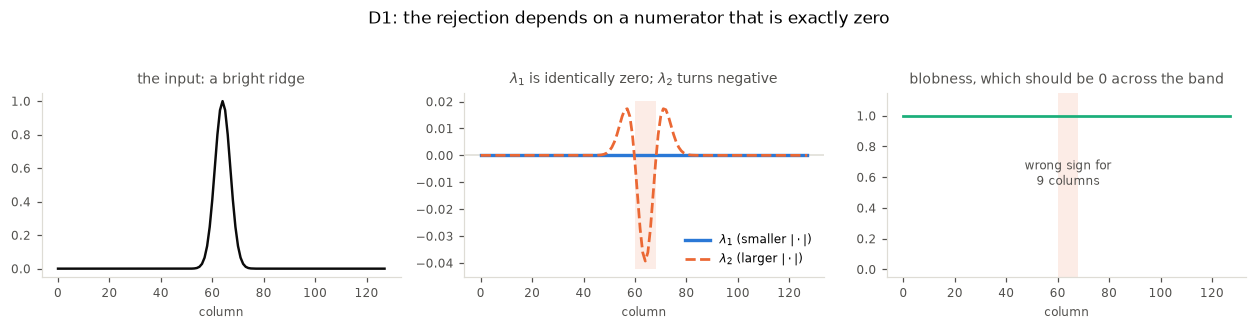

In [7]:
lam = eigen_pair(bright, 3)
row = lam[:, 64, :]
blob, _ = shipped_parts(bright, 3)

# The shaded band is computed, not drawn by hand: it is exactly the set of
# columns whose larger-magnitude eigenvalue has the wrong sign.
wrong_band = row[1] < 0
columns = np.arange(N)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.8))
axes[0].plot(bright[64], color=INK, lw=1.6)
recede(axes[0], "the input: a bright ridge")

axes[1].axhline(0, color=GRID, lw=1)
axes[1].plot(columns, row[0], color=C_ONE, lw=2.2, label=r"$\lambda_1$ (smaller $|\cdot|$)")
axes[1].plot(columns, row[1], color=C_TWO, lw=1.8, ls="--", label=r"$\lambda_2$ (larger $|\cdot|$)")
recede(axes[1], r"$\lambda_1$ is identically zero; $\lambda_2$ turns negative")
axes[1].legend(frameon=False, fontsize=8, loc="lower right")

axes[2].plot(columns, blob[64], color=C_THREE, lw=1.8)
recede(axes[2], "blobness, which should be 0 across the band")
axes[2].set_ylim(-0.05, 1.15)

for ax in axes[1:]:
    ax.fill_between(columns, *ax.get_ylim(), where=wrong_band,
                    color=C_TWO, alpha=0.12, lw=0)
axes[2].annotate(f"wrong sign for\n{wrong_band.sum()} columns", (64, 0.55),
                 ha="center", fontsize=8, color=MUTED)
for ax in axes:
    ax.set_xlabel("column", fontsize=8, color=MUTED)
fig.suptitle("D1: the rejection depends on a numerator that is exactly zero", y=1.05)
fig.tight_layout()

In [8]:
print(f"at the ridge centre:  lambda1 = {row[0][64]:.3e}   lambda2 = {row[1][64]:.3e}")
print(f"  clipped denominator = {max(row[1][64], 1e-10):.1e}")
print(f"  R_b = {abs(row[0][64]) / max(row[1][64], 1e-10):.4f}"
      f"   blobness = {blob[64, 64]:.4f}   (should be 0)")

at the ridge centre:  lambda1 = 0.000e+00   lambda2 = -3.928e-02
  clipped denominator = 1.0e-10
  R_b = 0.0000   blobness = 1.0000   (should be 0)


### 2.1 How wide is the leak?

The rejection survives only while $|\lambda_1|$ is large enough that
$|\lambda_1|/10^{-10}$ is large. Solving $\exp(-R_b^2/2\beta^2) > \theta$ for
$\beta = 1/2$ gives the threshold on $|\lambda_1|$ below which blobness exceeds
$\theta$ — that is, below which a wrong-polarity pixel is scored as a vessel.

In [9]:
BETA = 0.5

pd.DataFrame(
    [{"blobness above": theta,
      "needs |lambda1| below": f"{np.sqrt(-2 * BETA**2 * np.log(theta)) * 1e-10:.2e}"}
     for theta in (0.5, 0.01)]).set_index("blobness above")

,needs |lambda1| below
blobness above,
0.50,5.89e-11
0.01,1.52e-10


Those thresholds are minute, so the temptation is to say the leak cannot happen
on real data. It has to be checked at every scale rather than one, because
$|\lambda_1|$ shrinks as σ grows.

In [10]:
def leak_census(image, sigmas, beta=BETA):
    """Wrong-sign pixels, and how many of them the clipped divide lets through."""
    out = []
    for sigma in sigmas:
        eigvals = eigen_pair(image, sigma)
        wrong = eigvals[1] < 0                 # wrong sign for black_ridges=True
        blobness, _ = shipped_parts(image, sigma)
        out.append({"sigma": sigma,
                    "wrong-sign pixels": f"{wrong.mean():.1%}",
                    "smallest |lambda1| there": f"{np.abs(eigvals[0][wrong]).min():.2e}",
                    "leak, blobness > 0.5": int((blobness[wrong] > 0.5).sum()),
                    "leak, blobness > 0.01": int((blobness[wrong] > 0.01).sum())})
    return pd.DataFrame(out).set_index("sigma")


leak_census(PHOTO, SIGMAS)

,wrong-sign pixels,smallest |lambda1| there,"leak, blobness > 0.5","leak, blobness > 0.01"
sigma,,,,
1,49.9%,8.53e-09,0,0
3,50.2%,8.91e-09,0,0
5,51.8%,4.67e-09,0,0
7,52.4%,1.62e-09,0,0
9,52.2%,1.39e-11,1,2


In [11]:
print("straight synthetic ridges, |lambda1| at the centre:")
for width in (1.0, 3.0, 8.0):
    ridge = np.exp(-((cols - 64) ** 2) / (2 * width**2))
    print(f"   width {width:>4}: {abs(eigen_pair(ridge, 3)[0][centre]):.2e}")

straight synthetic ridges, |lambda1| at the centre:
   width  1.0: 0.00e+00
   width  3.0: 0.00e+00
   width  8.0: 0.00e+00


So the leak is not quite absent from photographs. On `camera` it is silent at
σ = 1 through 7 and fires at σ = 9, where a single pixel is scored above 0.5 and
two above 0.01 out of 65536 — because $|\lambda_1|$ there has fallen to
$1.4\times10^{-11}$, below the threshold in the table. A σ = 3 scan alone would
have reported nothing and invited the stronger claim.

The honest summary is that D1 is vanishingly rare on photographs and universal
on clean ridges: every exactly straight ridge has $\lambda_1 = 0$ along it, so
every one of them leaks completely. That is every construction anyone would
write a unit test or a documentation example around. `skimage`'s own
`test_ridges.py` does not catch it: its polarity tests compare
`f(dark, black_ridges=True)` against `f(bright, black_ridges=False)`, a symmetry
that holds trivially because the implementation negates the image, and never
assert that a ridge of the wrong polarity scores zero.

### 2.2 The fix: test the sign, do not divide by it

Both ITK and the `jerman` filter proposed in
[#8074](https://github.com/scikit-image/scikit-image/pull/8074) reject by an
explicit comparison rather than by arranging for a division to explode. ITK's
`HessianToObjectnessMeasureImageFilter` is the clearest statement of it:

```cpp
if ((m_BrightObject && sortedEigenValues[i] > 0.0) ||
    (!m_BrightObject && sortedEigenValues[i] < 0.0))
  { signConstraintsSatisfied = false; break; }
```

The same thing in NumPy, keeping the division away from the masked pixels:

In [12]:
def fixed_parts(image, sigma, beta=0.5, power=0.0, **kwargs):
    """Blobness and S with an explicit sign test instead of a clipped divide."""
    eigvals = eigen_pair(image, sigma, power=power, **kwargs)
    lambda1, lambda2 = eigvals[0], eigvals[1]
    right_sign = lambda2 > 0                    # dark ridge, after any negation
    r_b = np.abs(lambda1) / np.where(right_sign, lambda2, 1.0)
    blobness = np.where(right_sign, np.exp(-r_b**2 / (2 * beta**2)), 0.0)
    return blobness, np.sqrt((eigvals**2).sum(0))

In [13]:
def single_scale(parts_fn, image, sigma, gamma, black_ridges=True):
    """One scale of vesselness, given a `*_parts` function."""
    blobness, norm = parts_fn(-image if not black_ridges else image, sigma)
    return blobness * (1 - np.exp(-norm**2 / (2 * gamma**2)))


GAMMA_DEMO = np.sqrt((eigen_pair(bright, 3) ** 2).sum(0)).max() / 2
report = {}
for label, fn in (("shipped", shipped_parts), ("sign test", fixed_parts)):
    report[label] = {
        "black_ridges=True": single_scale(fn, bright, 3, GAMMA_DEMO, True)[centre],
        "black_ridges=False": single_scale(fn, bright, 3, GAMMA_DEMO, False)[centre],
    }
pd.DataFrame(report).round(6)

,shipped,sign test
black_ridges=True,0.864665,0.000000
black_ridges=False,0.864665,0.864665


The right-polarity answer is untouched; the wrong-polarity answer goes from the
largest value the filter can produce to zero. That ceiling is worth naming: with
$\gamma = \tfrac12\max_\mathbf{x} S$ the structuredness gate at the most
curved pixel is $1 - \exp(-S^2/2\gamma^2) = 1 - e^{-2} \approx 0.8647$, so a
single-scale `frangi` with the default γ cannot exceed that. A wrong-polarity
ridge was scoring exactly it.

## 3. D2 — no scale selection on ridges

`frangi` is documented as returning the "maximum of pixels across all scales",
which presupposes that different scales can win. On the structures the filter
is written for — straight ridges — they cannot, because $S$ falls with σ while
blobness stays pegged at 1. That is the defect #7711 reports. The argument
needs care: $R_b$ is invariant under *scaling* the Hessian, not under *changing*
σ, which re-smooths the image and can move $R_b$. Scale selection through
blobness is therefore possible in principle. On an ideal ridge it never
arrives, because $\lambda_1 = 0$ at every scale.

### 3.0 Why $S$ falls on a Gaussian ridge

A unit-height Gaussian ridge of width $w$,
$I_0(x) = \exp\!\bigl(-x^2/(2w^2)\bigr)$, smoothed by a Gaussian of width σ is
again Gaussian, with variance $v = w^2 + \sigma^2$ and peak height
$w/\sqrt{v}$:

$$
L(x, \sigma)
= \frac{w}{\sqrt{v}}\,
\exp\!\Bigl(-\frac{x^2}{2v}\Bigr).
$$

The cross-ridge second derivative on the axis is therefore

$$
\partial_{xx} L(0, \sigma)
= -\frac{w}{v^{3/2}}
= -\,w\,(w^2 + \sigma^2)^{-3/2},
$$

which is strictly decreasing in σ for every $w > 0$. Along the ridge
$\partial_{yy} L = 0$, so $S = |\partial_{xx} L|$ and the same falloff holds
for Frangi's Hessian norm. Multiplying by $\sigma^{2\gamma_L}$ is exactly
Lindeberg's normalisation of a second derivative — the same factor
`on_meijering.md` §5.1 derives — and is the reason any finite scale can win.

That $\partial_{yy} L = 0$ is also what pegs blobness at 1: it makes
$\lambda_1 = 0$, hence $R_b = 0$, at *every* scale rather than at the one scale
§2 happened to sample. Both statements are checked below.

In [14]:
# A ridge is constant along its length, so a few rows are enough; reflecting a
# constant gives the same constant, so the row border cannot contaminate this.
STRIP = (24, 220)
strip_cols = np.indices(STRIP, dtype=float)[1]
SCAN = np.arange(1, 16.01, 0.5)
MIDDLE = (STRIP[0] // 2, 110)


def axis_profile(width, power=0.0):
    """S at the centre of a ridge of given width, across scales.

    Multiplying the Hessian by sigma**power multiplies both eigenvalues, and
    so S, by exactly that factor - so one scan serves every exponent.
    """
    ridge = -np.exp(-((strip_cols - MIDDLE[1]) ** 2) / (2 * width**2))
    base = np.array([np.sqrt((eigen_pair(ridge, s) ** 2).sum(0))[MIDDLE]
                     for s in SCAN])
    return base * SCAN**power


PROFILES = {w: axis_profile(w) for w in (2.0, 4.0, 6.0, 10.0)}


def falloff_law(width, exponent=-1.5):
    """The continuous prediction w (w^2 + sigma^2)^exponent, on the scan."""
    return width * (width**2 + SCAN**2) ** exponent


def worst_deviation(measured, predicted):
    """Largest relative gap between two curves, each normalised at sigma = 1."""
    a, b = measured / measured[0], predicted / predicted[0]
    return np.abs(a / b - 1).max()

Correlation is the wrong instrument here and it is worth saying why, because it
looks like strong evidence. Two curves that both decay smoothly correlate at
better than 0.99 whatever their exponents, so a high correlation cannot
distinguish the predicted law from a wrong one. The largest relative deviation
can.

In [15]:
CANDIDATES = {
    "w (w²+σ²)^(-3/2)   predicted": falloff_law(4.0, -1.5),
    "  (w²+σ²)^(-1)     wrong": (4.0**2 + SCAN**2) ** -1.0,
    "  (w²+σ²)^(-2)     wrong": (4.0**2 + SCAN**2) ** -2.0,
    "  exp(-σ/4)        wrong": np.exp(-SCAN / 4),
}
measured = PROFILES[4.0]
pd.DataFrame(
    [{"candidate law": name,
      "correlation": f"{np.corrcoef(measured / measured[0], law / law[0])[0, 1]:.6f}",
      "worst relative deviation": f"{worst_deviation(measured, law):.1%}"}
     for name, law in CANDIDATES.items()]).set_index("candidate law")

,correlation,worst relative deviation
candidate law,,
w (w²+σ²)^(-3/2) predicted,0.999996,0.5%
(w²+σ²)^(-1) wrong,0.990581,74.9%
(w²+σ²)^(-2) wrong,0.993333,302.1%
exp(-σ/4) wrong,0.992014,46.6%


Every candidate correlates above 0.99, the wrong ones included. The deviation
column separates them: sub-1% for the predicted law against tens to hundreds of
percent for the rest. So check the law on every width with that, and check the
monotonicity claim on every width too rather than on one.

In [16]:
def along_ridge(width):
    """Largest |lambda1| and smallest blobness at the ridge centre, over SCAN."""
    ridge = -np.exp(-((strip_cols - MIDDLE[1]) ** 2) / (2 * width**2))
    worst_lambda1, least_blobness = 0.0, 1.0
    for sigma in SCAN:
        eigvals = eigen_pair(ridge, sigma)
        blobness, _ = shipped_parts(ridge, sigma)
        worst_lambda1 = max(worst_lambda1, abs(eigvals[0][MIDDLE]))
        least_blobness = min(least_blobness, blobness[MIDDLE])
    return worst_lambda1, least_blobness


rows_30 = []
for width, profile in PROFILES.items():
    worst_lambda1, least_blobness = along_ridge(width)
    rows_30.append({
        "ridge width w": width,
        "strictly decreasing in σ": bool(np.all(np.diff(profile) < 0)),
        "worst deviation from the law": f"{worst_deviation(profile, falloff_law(width)):.2%}",
        "largest |λ₁| over the scan": worst_lambda1,
        "smallest blobness over the scan": least_blobness,
    })
pd.DataFrame(rows_30).set_index("ridge width w")

,strictly decreasing in σ,worst deviation from the law,largest |λ₁| over the scan,smallest blobness over the scan
ridge width w,,,,
2.0,True,0.96%,0.0,1.0
4.0,True,0.52%,0.0,1.0
6.0,True,0.46%,0.0,1.0
10.0,True,0.43%,0.0,1.0


$S$ falls monotonically at every width, tracks the continuous law to within a
percent, and $\lambda_1$ is zero — not small, zero — at every scale on the
scan, so blobness never leaves 1. On an ideal ridge the only σ-dependence left
really is $S$, which is what makes the shipped filter's maximum over scales
collapse onto the finest one.

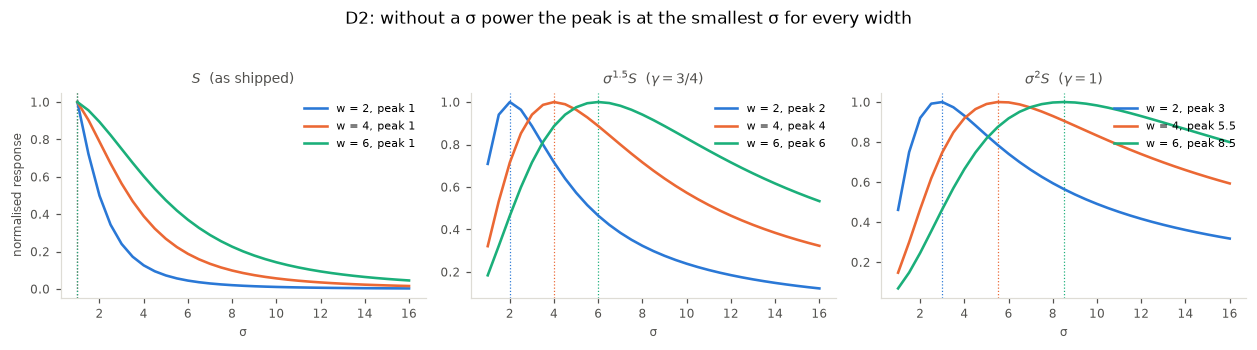

In [17]:
WIDTHS = (2.0, 4.0, 6.0)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), sharex=True)
for ax, power, label in zip(
        axes, (0.0, 1.5, 2.0),
        (r"$S$  (as shipped)", r"$\sigma^{1.5} S$  ($\gamma=3/4$)",
         r"$\sigma^{2} S$  ($\gamma=1$)")):
    for width, colour in zip(WIDTHS, (C_ONE, C_TWO, C_THREE)):
        curve = PROFILES[width] * SCAN**power
        curve = curve / curve.max()
        peak = SCAN[curve.argmax()]
        ax.plot(SCAN, curve, color=colour, lw=1.7, label=f"w = {width:g}, peak {peak:g}")
        ax.axvline(peak, color=colour, lw=0.8, ls=":", zorder=0)
    recede(ax, label)
    ax.set_xlabel("σ", fontsize=8, color=MUTED)
    ax.legend(frameon=False, fontsize=7.5, loc="upper right")
axes[0].set_ylabel("normalised response", fontsize=8, color=MUTED)
fig.suptitle("D2: without a σ power the peak is at the smallest σ for every width",
             y=1.04)
fig.tight_layout()

The left panel is the shipped filter: three ridges of quite different width,
three curves that all peak at the smallest scale on the scan. The other two
panels apply Lindeberg's γ-normalisation, a factor $\sigma^{2\gamma}$ on a
second derivative. The peaks then land where the theory says.

In [18]:
selection = []
for width, base in PROFILES.items():
    row_out = {"true width w": width}
    for power, label in ((0.0, "S"), (1.5, "σ^1.5 S"), (2.0, "σ^2 S")):
        row_out[label] = SCAN[(base * SCAN**power).argmax()]
    row_out["predicted w"] = width
    row_out["predicted w·√2"] = round(width * np.sqrt(2), 2)
    selection.append(row_out)
pd.DataFrame(selection).set_index("true width w")

,S,σ^1.5 S,σ^2 S,predicted w,predicted w·√2
true width w,,,,,
2.0,1.0,2.0,3.0,2.0,2.83
4.0,1.0,4.0,5.5,4.0,5.66
6.0,1.0,6.0,8.5,6.0,8.49
10.0,1.0,10.0,14.0,10.0,14.14


`σ^1.5` selects the ridge's own width and `σ^2` selects $w\sqrt2$ — exactly the
two calibrations `on_meijering.md` §5 derives from Lindeberg (1998) §5.6.1,
now measured on Frangi's $S$ rather than on Meijering's eigenvalue. The choice
of exponent is the same open question in both filters.

On a photograph the same collapse shows up wherever vesselness is non-trivial.
Below a small floor the argmax over scales is noise among values near zero; above
it, without a σ power, the finest scale wins every time under the usual γ
(half the Hessian norm at `sigmas[0]`).

In [19]:
# Practical D2 on a photograph: who wins where vesselness is non-trivial?
# (Same arithmetic as frangi_cache/fuse below; inlined so this section runs alone.)
gamma_usual = np.sqrt((eigen_pair(PHOTO, SIGMAS[0]) ** 2).sum(0)).max() / 2
stack_d2 = []
for sigma in SIGMAS:
    blob, norm = shipped_parts(PHOTO, sigma)
    stack_d2.append(blob * (1 - np.exp(-norm**2 / (2 * gamma_usual**2))))
stack_d2 = np.stack(stack_d2)
vmax_d2 = stack_d2.max(0)
won_d2 = np.array(SIGMAS)[stack_d2.argmax(0)]
FLOOR_V = 0.01
live = vmax_d2 > FLOOR_V
print(f"camera, γ from sigmas[0]={SIGMAS[0]}: "
      f"{live.mean():.1%} of pixels have V > {FLOOR_V}")
print(f"  of those, won by σ={SIGMAS[0]}: {np.mean(won_d2[live] == SIGMAS[0]):.1%}")
print(f"  of those, won by any larger σ: "
      f"{np.mean(won_d2[live] > SIGMAS[0]):.1%}")

camera, γ from sigmas[0]=1: 10.1% of pixels have V > 0.01
  of those, won by σ=1: 100.0%
  of those, won by any larger σ: 0.0%


Two caveats keep this from being "every pixel, every γ", and the second is
worth measuring rather than conceding. First, among pixels with $V \approx 0$
the argmax is meaningless, and a majority of the frame sits there. Second, if γ
is driven small enough that the structuredness gate saturates at several scales,
the gate stops discriminating and blobness decides instead — so a coarser scale
can win. Shrinking γ below the default shows exactly that.

In [20]:
def winners_at_gamma(gamma, floor=FLOOR_V):
    """Share of the live set won by each sigma, at one gamma."""
    stack = np.stack([blob * (1 - np.exp(-norm**2 / (2 * gamma**2)))
                      for blob, norm in
                      (shipped_parts(PHOTO, sigma) for sigma in SIGMAS)])
    fused, won = stack.max(0), np.array(SIGMAS)[stack.argmax(0)]
    live_here = fused > floor
    return live_here.mean(), {s: np.mean(won[live_here] == s) for s in SIGMAS}


rows_gamma = []
for divisor in (1, 10, 100, 1000):
    share_live, shares = winners_at_gamma(gamma_usual / divisor)
    rows_gamma.append({"gamma": f"γ₀/{divisor}",
                       "live share of frame": f"{share_live:.1%}",
                       **{f"σ={s}": f"{v:.1%}" for s, v in shares.items()}})
pd.DataFrame(rows_gamma).set_index("gamma")

,live share of frame,σ=1,σ=3,σ=5,σ=7,σ=9
gamma,,,,,,
γ₀/1,10.1%,100.0%,0.0%,0.0%,0.0%,0.0%
γ₀/10,37.2%,80.5%,15.0%,4.1%,0.3%,0.0%
γ₀/100,67.9%,62.4%,21.7%,8.3%,3.6%,4.0%
γ₀/1000,79.2%,43.4%,26.3%,11.2%,7.5%,11.5%


At the default γ the finest scale takes the whole live set. Divide γ by a
thousand and the gate is saturated almost everywhere, blobness takes over, and
σ = 9 wins a tenth of a much larger live set. So the defect is not that coarser
scales are unreachable in floating point; it is that the filter never selects a
ridge's own width, and that non-trivial vesselness under the default γ collapses
to the finest scale.

### 3.1 What the paper asks for

Frangi *et al.* define their derivatives in normalised form,

$$
\frac{\partial}{\partial x} L(\mathbf{x}, s) = s^{\gamma}\, L(\mathbf{x}) *
\frac{\partial}{\partial x} G(\mathbf{x}, s),
$$

so a second derivative carries $s^{2\gamma}$ and the Hessian is scaled as a
whole. scikit-image applies no factor at all, which is $\gamma = 0$ — the one
value Lindeberg's analysis excludes, because it is the value for which no
finite scale is ever selected. Issue
[#7711](https://github.com/scikit-image/scikit-image/issues/7711) reports the
symptom directly: "Due to the missing scale corrections only the smallest scale
affects the filter output."

The repair is one multiplication, and it belongs on the Hessian so that both
$R_b$ and $S$ see a consistently scaled matrix.

The same statement on the whole vesselness rather than on $S$ alone. γ has to
be chosen so the structuredness gate does not saturate: once it reaches 1 at
several scales the maximum is a tie, and `max` then returns whichever came
first, which says nothing about scale selection.

In [21]:
SIGMA_GRID = (1, 2, 3, 4, 6, 8, 10, 12)
ridge6 = np.exp(-((strip_cols - MIDDLE[1]) ** 2) / (2 * 6.0**2))

rows_out = []
for power in (0.0, 1.5, 2.0):
    parts = {s: fixed_parts(-ridge6, s, power=power) for s in SIGMA_GRID}
    # Docstring rule: gamma = half the largest Hessian norm over the scan.
    gamma = max(norm.max() for _, norm in parts.values()) / 2
    scores = {s: (b * (1 - np.exp(-n**2 / (2 * gamma**2))))[MIDDLE]
              for s, (b, n) in parts.items()}
    rows_out.append({"factor": f"sigma**{power}",
                     "winning sigma": max(scores, key=scores.get),
                     "scales within 1e-6 of the winner":
                         sum(v > max(scores.values()) - 1e-6 for v in scores.values())})
pd.DataFrame(rows_out).set_index("factor")

,winning sigma,scales within 1e-6 of the winner
factor,,
sigma**0.0,1,1
sigma**1.5,6,1
sigma**2.0,8,1


The width-6 ridge is won by σ = 1 with no exponent, by σ = 6 with
$\sigma^{1.5}$, and by σ = 8 with $\sigma^{2}$ — the same three answers as the
table above, now with the blobness factor and the gate included, and with the
tie count confirming the winner is unique.

## 4. D3 — the answer depends on the order of `sigmas`

`gamma=None` is resolved like this, with the assignment *inside* the scale
loop:

```python
for sigma in sigmas:                       # <- the loop
    ...
    s = np.sqrt((eigvals**2).sum(0))       # the Hessian norm
    if gamma is None:
        gamma = s.max() / 2                # rebinds the local name
        if gamma == 0:
            gamma = 1
    ...
```

On the first iteration the test is true and `gamma` becomes a number. On every
later iteration it is false. So γ is half the largest Hessian norm **at
`sigmas[0]`**, and since §3 established that $S$ falls with σ, the number
depends strongly on which scale happens to be written first.

γ spans a factor of 130 across sigmas = (1, 3, 5, 7, 9)


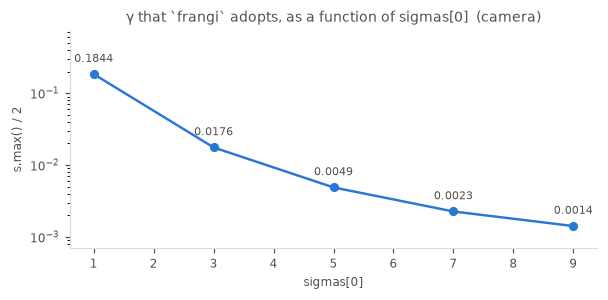

In [22]:
gammas = {s: np.sqrt((eigen_pair(PHOTO, s) ** 2).sum(0)).max() / 2 for s in SIGMAS}

fig, ax = plt.subplots(figsize=(5.6, 2.8))
ax.plot(list(gammas), list(gammas.values()), "o-", color=C_ONE, lw=1.6, ms=5)
ax.set_yscale("log")
ax.set_ylim(min(gammas.values()) / 2, max(gammas.values()) * 4)
recede(ax, "γ that `frangi` adopts, as a function of sigmas[0]  (camera)")
ax.set_xlabel("sigmas[0]", fontsize=8, color=MUTED)
ax.set_ylabel("s.max() / 2", fontsize=8, color=MUTED)
for s, g in gammas.items():
    ax.annotate(f"{g:.4f}", (s, g), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7, color=MUTED)
fig.tight_layout()
print(f"γ spans a factor of {max(gammas.values()) / min(gammas.values()):.0f}"
      f" across sigmas = {SIGMAS}")

Three ridges of different width, the same three scales, written twice.

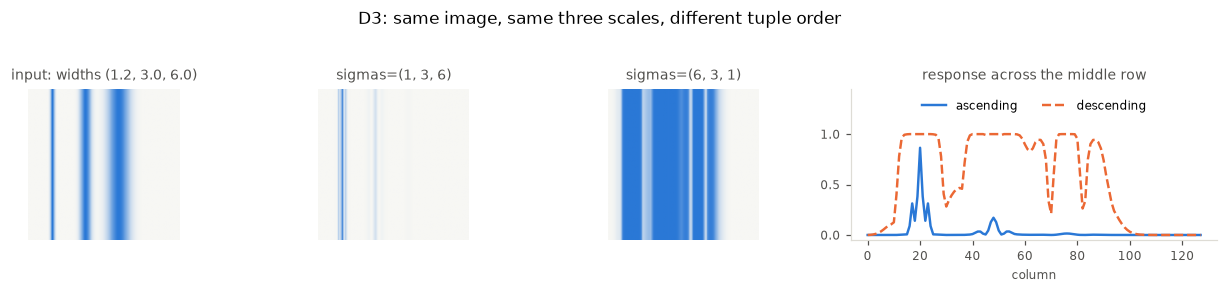

In [23]:
CENTRES, WIDTHS_DEMO = (20, 48, 76), (1.2, 3.0, 6.0)
three = sum(np.exp(-((cols - c) ** 2) / (2 * w**2))
            for c, w in zip(CENTRES, WIDTHS_DEMO))
TRIPLE = (1, 3, 6)
up = frangi(three, sigmas=TRIPLE, black_ridges=False)
down = frangi(three, sigmas=TRIPLE[::-1], black_ridges=False)

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.5),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
bare(axes[0], f"input: widths {WIDTHS_DEMO}")
axes[0].imshow(three, cmap=SEQ)
for ax, out, label in ((axes[1], up, f"sigmas={TRIPLE}"),
                       (axes[2], down, f"sigmas={TRIPLE[::-1]}")):
    bare(ax, label)
    ax.imshow(out, cmap=SEQ, vmin=0, vmax=1)
axes[3].plot(up[N // 2], color=C_ONE, lw=1.6, label="ascending")
axes[3].plot(down[N // 2], color=C_TWO, lw=1.6, ls="--", label="descending")
recede(axes[3], "response across the middle row")
axes[3].set_xlabel("column", fontsize=8, color=MUTED)
axes[3].set_ylim(-0.05, 1.45)
axes[3].set_yticks([0, 0.5, 1.0])
axes[3].legend(frameon=False, fontsize=8, loc="upper center", ncol=2)
fig.suptitle("D3: same image, same three scales, different tuple order", y=1.04)
fig.tight_layout()

In [24]:
mid = N // 2
pd.DataFrame(
    {"true width": WIDTHS_DEMO,
     f"sigmas={TRIPLE}": [up[mid, c] for c in CENTRES],
     f"sigmas={TRIPLE[::-1]}": [down[mid, c] for c in CENTRES]},
    index=pd.Index(CENTRES, name="ridge at column"),
).round(4)

,true width,"sigmas=(1, 3, 6)","sigmas=(6, 3, 1)"
ridge at column,,,
20,1.2,0.8647,1.0
48,3.0,0.1711,1.0
76,6.0,0.0148,1.0


Ascending, the filter reports one vessel: the narrow ridge scores 0.86 and the
widest 0.015, which reads as "not a vessel". Descending, all three saturate at
1.0 — and so, as the profile shows, does most of the background between them.
These are two different answers to *which of these is a vessel*, and the second
barely discriminates at all.

If the mechanism above is right, two orderings agree exactly when they share a
first element: six permutations, three predicted classes.

In [25]:
orbit = {}
for perm in permutations(SIGMAS[:3]):
    orbit.setdefault(round(float(frangi(PHOTO, sigmas=perm).sum()), 6), []).append(perm)

print(f"{len(orbit)} distinct outputs from 6 permutations;"
      f" total response spans a factor of {max(orbit) / min(orbit):.0f}")
pd.DataFrame([{"sum of output": k,
               "first sigma": sorted({p[0] for p in v}),
               "permutations": ", ".join(map(str, v))}
              for k, v in sorted(orbit.items())]).set_index("sum of output")

3 distinct outputs from 6 permutations; total response spans a factor of 28


,first sigma,permutations
sum of output,,
603.934947,[1],"(1, 3, 5), (1, 5, 3)"
8865.171407,[3],"(3, 1, 5), (3, 5, 1)"
17103.218730,[5],"(5, 1, 3), (5, 3, 1)"


### 4.1 The promise this breaks

Two documented contracts, both in `frangi`'s own docstring. The return value is

> `out` : Filtered image (**maximum of pixels across all scales**).

A maximum over a collection does not depend on the order of the collection, and
`sigmas` is documented as "Sigmas used as scales of filter" with no hint that
order matters. And the default γ is

> The default, None, uses **half of the maximum Hessian norm**.

Half of *the* maximum Hessian norm, not half of the maximum at one arbitrary
member of `sigmas`. Read literally, the docstring already describes the fix.

In [26]:
over_all = max(gammas.values())
print(f"'half of the maximum Hessian norm' over sigmas={SIGMAS}: {over_all:.6f}")
print("what frangi actually uses, per first sigma:")
for s, g in gammas.items():
    print(f"   sigmas[0] = {s}: {g:.6f}"
          f"{'   <- matches the docstring' if g == over_all else ''}")

'half of the maximum Hessian norm' over sigmas=(1, 3, 5, 7, 9): 0.184388
what frangi actually uses, per first sigma:
   sigmas[0] = 1: 0.184388   <- matches the docstring
   sigmas[0] = 3: 0.017605
   sigmas[0] = 5: 0.004892
   sigmas[0] = 7: 0.002263
   sigmas[0] = 9: 0.001418


### 4.2 The fix: resolve γ before the loop

Vesselness splits cleanly at γ, so the scale loop can compute everything else
first — at one Hessian per σ, the same number the shipped loop performs.

In [27]:
def frangi_cache(image, sigmas, parts_fn=fixed_parts, power=0.0,
                 black_ridges=True, mode="reflect"):
    """`parts_fn` at every scale, computed once."""
    image = image.astype(float, copy=False)
    if not black_ridges:
        image = -image
    return [parts_fn(image, sigma, power=power, mode=mode) for sigma in sigmas]


def fuse(cached, gamma):
    """Maximum over scales. `gamma` is a number, or "per-scale"."""
    stack = []
    for blobness, norm in cached:
        g = (norm.max() / 2 or 1.0) if gamma == "per-scale" else gamma
        stack.append(blobness * (1 - np.exp(-norm**2 / (2 * g**2))))
    return np.stack(stack)


def resolved_gamma(cached):
    """Half the largest Hessian norm over every scale, as the docstring says."""
    return max(norm.max() for _, norm in cached) / 2 or 1.0

In [28]:
def hoisted(image, sigmas, **kwargs):
    cached = frangi_cache(image, sigmas, parts_fn=shipped_parts, **kwargs)
    return fuse(cached, resolved_gamma(cached)).max(0)


TRIO = SIGMAS[:3]
base = hoisted(PHOTO, TRIO)
worst_fixed = max(np.abs(hoisted(PHOTO, p) - base).max() for p in permutations(TRIO))
shipped_base = frangi(PHOTO, sigmas=TRIO)
worst_shipped = max(np.abs(frangi(PHOTO, sigmas=p) - shipped_base).max()
                    for p in permutations(TRIO))
print(f"worst max|difference| over all six permutations of {TRIO}")
print(f"   shipped {worst_shipped:.4f}")
print(f"   hoisted {worst_fixed:.4f}")
print(f"\nhoisted vs shipped on the ascending list:"
      f" {np.abs(hoisted(PHOTO, SIGMAS) - frangi(PHOTO, sigmas=SIGMAS)).max():.3g}")

worst max|difference| over all six permutations of (1, 3, 5)
   shipped 0.9942
   hoisted 0.0000



hoisted vs shipped on the ascending list: 0


On an ascending list the hoisted version reproduces today's output exactly,
because §3 showed $S$ falls with σ, so the maximum over all scales is attained
at `min(sigmas)`, which for a sorted list is also `sigmas[0]`. **That ceases to
be true once D2 is fixed**, and §10 returns to the consequence.

## 5. D4 — γ = None is a whole-image statistic

Fixing the order does not make the filter local. `s.max()` is a maximum over
every pixel, so a single bright speck anywhere in the frame sets the contrast
reference for the whole image. `on_meijering.md` §1 uses the same two probes.

In [29]:
def far_field(fn, image, spot=(0, 0), value=10.0, keep=100):
    """Relative change 100 px away when one distant pixel is brightened."""
    edited = image.copy()
    edited[spot] = value
    before, after = fn(image), fn(edited)
    far = (slice(keep, None), slice(keep, None))
    return (np.abs(before[far] - after[far]).max()
            / max(np.abs(before[far]).max(), 1e-12))


# `truncate` defaults to 4, so the sigma=9 kernel reaches 36 px. The margin has
# to exceed that, or the probe measures the border defect (D5) instead.
def crop_change(fn, image, size=140, margin=40):
    """Change in the shared interior when the surroundings are cropped away."""
    whole, part = fn(image)[:size, :size], fn(image[:size, :size])
    inner = (slice(margin, -margin),) * 2
    return (np.abs(whole[inner] - part[inner]).max()
            / max(np.abs(whole[inner]).max(), 1e-12))


probes = {}
for label, fn in (
        ("meijering", lambda im: meijering(im, sigmas=SIGMAS)),
        ("sato", lambda im: sato(im, sigmas=SIGMAS, mode="reflect")),
        ("frangi, gamma=None", lambda im: frangi(im, sigmas=SIGMAS)),
        ("frangi, gamma=15", lambda im: frangi(im, sigmas=SIGMAS, gamma=15))):
    probes[label] = {"one distant pixel": far_field(fn, PHOTO),
                     "crop the surroundings": crop_change(fn, PHOTO)}
pd.DataFrame(probes).T.map(lambda v: f"{v:.2%}")

,one distant pixel,crop the surroundings
meijering,85.21%,6.79%
sato,0.00%,0.00%
"frangi, gamma=None",95.70%,0.00%
"frangi, gamma=15",0.00%,0.00%


`sato` is local under both probes, as a filter should be. `frangi` is not, and
stops being non-local the moment γ is given explicitly — which identifies γ as
the sole cause.

Two cautions about reading that table. The margin matters: if it is smaller
than the widest kernel support, the crop probe measures the border defect of §6
rather than non-locality. And the crop probe can read 0.00% for `frangi` even
at `gamma=None` — that is not evidence of locality, only evidence that this
crop happened to keep the pixel that sets the maximum. A probe returning zero
proves nothing on its own; the far-field column is the one doing the work here.

In [30]:
# The σ=9 kernel at truncate=4 reaches 36 px; margin=20 sits inside that support.
for margin in (20, 40):
    print(f"sato crop_change at margin={margin}: "
          f"{crop_change(lambda im: sato(im, sigmas=SIGMAS, mode='reflect'), PHOTO, margin=margin):.2%}")

sato crop_change at margin=20: 4.41%


sato crop_change at margin=40: 0.00%


There is no repair that keeps `gamma=None` and restores locality, because the
default is *defined* as an image-wide statistic. The honest options are to
document it, or to give γ a local meaning, and only the first is a bug fix.
`on_meijering.md` faces the same wall for the same reason.

### 5.1 How much does γ disturb the comparison between scales?

It is tempting to say a single frozen γ rescales every scale alike and so
leaves the cross-scale comparison intact, unlike a per-scale divisor. That is
the wrong reason for the right distinction. The structuredness gate is **not**
linear in $S$, and different scales arrive with different $S$, so changing γ
reweights the scales against each other even when one γ is used for all of
them.

In [31]:
def winning_sigma_map(image, sigmas, gamma, **kwargs):
    """Which sigma gives the largest vesselness at each pixel."""
    cached = frangi_cache(image, sigmas, parts_fn=shipped_parts, **kwargs)
    return np.array(sigmas)[fuse(cached, gamma).argmax(0)]


cached_photo = frangi_cache(PHOTO, SIGMAS, parts_fn=shipped_parts)
maps = {f"γ from sigma={s}": np.array(SIGMAS)[fuse(cached_photo, gammas[s]).argmax(0)]
        for s in (SIGMAS[0], SIGMAS[-1])}
maps["γ per scale"] = np.array(SIGMAS)[fuse(cached_photo, "per-scale").argmax(0)]
# Vesselness under the usual γ; used to ignore near-zero argmax noise below.
V_REF = fuse(cached_photo, gammas[SIGMAS[0]]).max(0)
V_FLOOR = 0.01

pd.DataFrame({label: {s: f"{np.mean(won == s):.1%}" for s in SIGMAS}
              for label, won in maps.items()}).T

,1,3,5,7,9
γ from sigma=1,64.9%,18.1%,7.2%,4.0%,5.8%
γ from sigma=9,61.1%,20.0%,8.7%,4.3%,5.9%
γ per scale,41.4%,12.3%,9.3%,10.2%,26.8%


In [32]:
low, high = maps[f"γ from sigma={SIGMAS[0]}"], maps[f"γ from sigma={SIGMAS[-1]}"]
live = V_REF > V_FLOOR
print("fraction of pixels where the winning sigma changes")
print(f"  all pixels, frozen γ (sigmas[0]=1 vs 9) : {np.mean(low != high):.1%}")
print(f"  all pixels, frozen γ vs γ per scale     : "
      f"{np.mean(maps['γ per scale'] != low):.1%}")
print(f"  among V > {V_FLOOR}, frozen γ reorder   : {np.mean(low[live] != high[live]):.1%}"
      f"  ({live.mean():.1%} of the image)")
print(f"  among V > {V_FLOOR}, vs γ per scale     : "
      f"{np.mean(maps['γ per scale'][live] != low[live]):.1%}")

fraction of pixels where the winning sigma changes
  all pixels, frozen γ (sigmas[0]=1 vs 9) : 5.7%
  all pixels, frozen γ vs γ per scale     : 43.0%
  among V > 0.01, frozen γ reorder   : 18.1%  (10.1% of the image)
  among V > 0.01, vs γ per scale     : 44.6%


The distinction is quantitative, not categorical. All-pixel argmax counts are
diluted by the near-zero background, where the winning scale is noise among
values close to zero; restricting to $V > 0.01$, about a tenth of the frame
under the usual γ, is the comparison that bears on vessel selection. On that
set, reordering `sigmas` moves the winning scale at **18% of the pixels with
$V > 0.01$**, and a per-scale γ moves it at **45% of the same set** — against
6% and 43% when the background is allowed to dilute both. A frozen γ is the
milder of the two, not an innocent one, and restricting to the live set makes
the reordering defect three times larger, not smaller.

## 6. D5 — the border rim

The last defect is not `frangi`'s own. `hessian_matrix` filters each axis in
turn with a Gaussian and then differentiates, so the boundary extension is
applied to an already-smoothed array rather than to the image; `on_hessian.md`
diagnoses it and gives fixes A and C. The consequence in `frangi` is a bright
rim.

A reference that must agree: extend the image symmetrically, filter, and crop
back. With `mode='reflect'` an exact implementation gives the same answer on the
shared pixels.

In [33]:
def taps(sigma, order, trunc=8):
    """The 1-D kernel `gaussian_filter` builds, from the explicit formula."""
    lw = int(trunc * sigma + 0.5)
    x = np.arange(-lw, lw + 1).astype(float)
    g = np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    if order == 0:
        return x, g
    if order == 1:
        return x, g * (x / sigma**2)
    return x, g * ((x**2 - sigma**2) / sigma**4)


def corrected_taps(sigma, order):
    """Fix C of `on_hessian.md`: repair the discrete moments."""
    x, g = taps(sigma, 0)
    _, k = taps(sigma, order)
    if order == 0:
        return x, g
    if order == 1:
        return x, k / (k * x).sum()             # exact on f = x
    k = k - k.sum() * g                         # annihilate constants
    return x, k / ((k * x**2).sum() / 2)        # exact on f = x**2 / 2


def repaired_eigen_pair(image, sigma, mode="reflect", power=0.0):
    """Fix A (one pass per element) + fix C, then the 2x2 eigenvalues."""
    def element(orders):
        out = image
        for axis, order in enumerate(orders):
            out = ndi.correlate1d(out, corrected_taps(sigma, order)[1],
                                  axis=axis, mode=mode)
        return out

    hrr, hrc, hcc = (element(o) for o in ((2, 0), (1, 1), (0, 2)))
    total = hrr + hcc
    spread = np.sqrt((hrr - hcc) ** 2 + 4 * hrc**2)
    eigvals = np.stack([(total + spread) / 2, (total - spread) / 2]) * sigma**power
    return np.take_along_axis(eigvals, abs(eigvals).argsort(0), 0)

In [34]:
def vesselness(image, sigmas, gamma, eig_fn, beta=0.5, mode="reflect"):
    """Whole filter, parameterised by the eigenvalue routine."""
    out = np.zeros_like(image, dtype=float)
    for sigma in sigmas:
        eigvals = eig_fn(image, sigma, mode=mode)
        lambda1, lambda2 = eigvals[0], eigvals[1]
        ok = lambda2 > 0
        r_b = np.abs(lambda1) / np.where(ok, lambda2, 1.0)
        blobness = np.where(ok, np.exp(-r_b**2 / (2 * beta**2)), 0.0)
        norm = np.sqrt((eigvals**2).sum(0))
        out = np.maximum(out, blobness * (1 - np.exp(-norm**2 / (2 * gamma**2))))
    return out


# A crop, so the padded copy stays small: the rim is what is under test.
ZOOM = 16
CROP = PHOTO[:128, :128]
PAD, GAMMA_FIXED, BORDER_SIGMAS = 40, 0.05, (1, 3, 5)
extended = np.pad(CROP, PAD, mode="symmetric")        # matches mode='reflect'
border = {}
for label, eig_fn in (("shipped Hessian", eigen_pair),
                      ("Hessian fixes A + C", repaired_eigen_pair)):
    here = vesselness(CROP, BORDER_SIGMAS, GAMMA_FIXED, eig_fn)
    there = vesselness(extended, BORDER_SIGMAS, GAMMA_FIXED, eig_fn)[PAD:-PAD, PAD:-PAD]
    delta = np.abs(here - there) / here.max()
    border[label] = {f"beyond {k} px": delta[k:-k, k:-k].max() if k else delta.max()
                     for k in (0, 1, 3, 10)}
    border[label]["_map"] = delta
frames = {k: {kk: vv for kk, vv in v.items() if kk != "_map"} for k, v in border.items()}
for label, v in border.items():
    print(f"{label:<22} largest disagreement anywhere: {v['_map'].max():.3g}")
pd.DataFrame(frames).T.map(lambda v: f"{v:.2%}")

shipped Hessian        largest disagreement anywhere: 0.769
Hessian fixes A + C    largest disagreement anywhere: 0


,beyond 0 px,beyond 1 px,beyond 3 px,beyond 10 px
shipped Hessian,76.95%,6.74%,0.35%,0.00%
Hessian fixes A + C,0.00%,0.00%,0.00%,0.00%


Text(0.5, 1.03, 'D5: the disagreement is a rim, and fixes A + C remove it')

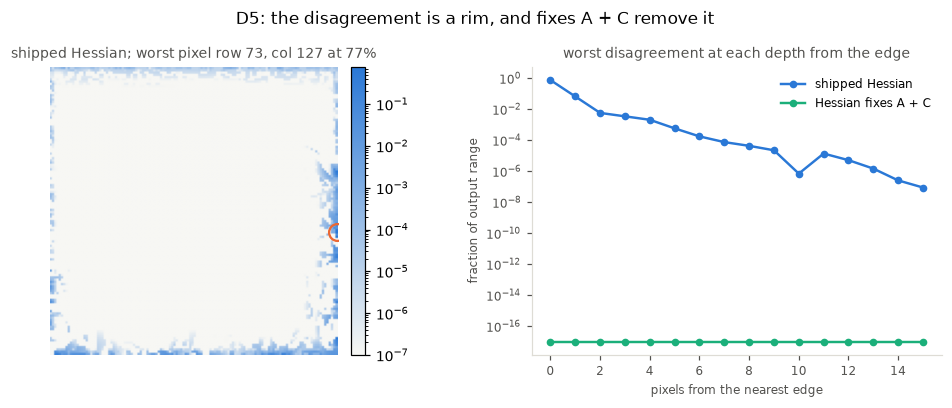

In [35]:
# The rim is one or two pixels wide and the error spans nine decades, so a
# linear colour scale shows nothing. Use a log norm, and let the code find
# where the worst pixel actually is rather than guessing a corner.
from matplotlib.colors import LogNorm

FLOOR = 1e-7
shipped_map = border["shipped Hessian"]["_map"]
hot = tuple(int(v) for v in np.unravel_index(shipped_map.argmax(), shipped_map.shape))

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.4),
                         gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.45})
im = axes[0].imshow(np.maximum(shipped_map, FLOOR), cmap=SEQ,
                    norm=LogNorm(vmin=FLOOR, vmax=shipped_map.max()))
axes[0].plot(hot[1], hot[0], "o", mfc="none", mec=C_TWO, ms=11, mew=1.5)
bare(axes[0], f"shipped Hessian; worst pixel row {hot[0]}, col {hot[1]}"
              f" at {shipped_map.max():.0%}")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

for (label, v), colour in zip(border.items(), (C_ONE, C_THREE)):
    # Worst disagreement among all pixels exactly k from the nearest edge.
    r, c = np.indices(v["_map"].shape)
    height, width = v["_map"].shape
    depth = np.minimum.reduce([r, c, height - 1 - r, width - 1 - c])
    profile = [v["_map"][depth == k].max() for k in range(ZOOM)]
    axes[1].semilogy(range(ZOOM), np.maximum(profile, 1e-17), "o-",
                     color=colour, lw=1.6, ms=4, label=label)
recede(axes[1], "worst disagreement at each depth from the edge")
axes[1].set_xlabel("pixels from the nearest edge", fontsize=8, color=MUTED)
axes[1].set_ylabel("fraction of output range", fontsize=8, color=MUTED)
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle("D5: the disagreement is a rim, and fixes A + C remove it", y=1.03)

With the shipped Hessian the disagreement is confined to a rim: about 77% of
the output range at the outermost pixel, an order of magnitude less one pixel
in, and below 1% by the third. With fixes A and C it is zero — not small, zero
to floating point — at every depth, which is the result `on_hessian.md` reports
for `frangi`, `sato` and `hessian` together. Nothing in `frangi` itself needs to
change.

## 7. D6 — `alpha` does nothing in 2-D

The plate-sensitivity factor $1 - \exp(-R_a^2/2\alpha^2)$ needs three
eigenvalues. In 2-D the code sets `r_a = np.inf`, so the factor is exactly 1 and
`alpha` cannot affect the result. The docstring describes `alpha` without
qualification.

In [36]:
ref = frangi(PHOTO, sigmas=SIGMAS, alpha=0.5, gamma=GAMMA_FIXED)
volume = np.stack([PHOTO[::2, ::2]] * 24, axis=0)
ref3 = frangi(volume, sigmas=[2], alpha=0.5, gamma=GAMMA_FIXED)
pd.DataFrame(
    [{"alpha": a,
      "2-D: max |diff| vs alpha=0.5":
          np.abs(frangi(PHOTO, sigmas=SIGMAS, alpha=a, gamma=GAMMA_FIXED) - ref).max(),
      "3-D: max |diff| vs alpha=0.5":
          np.abs(frangi(volume, sigmas=[2], alpha=a, gamma=GAMMA_FIXED) - ref3).max()}
     for a in (0.1, 2.0, 5.0)]).set_index("alpha").round(6)

,2-D: max |diff| vs alpha=0.5,3-D: max |diff| vs alpha=0.5
alpha,,
0.1,0.0,0.283397
2.0,0.0,0.478963
5.0,0.0,0.541594


Exactly zero in 2-D, non-zero in 3-D. This is a docstring fix, not a code fix:
add "has no effect for 2-D images" to the `alpha` entry.

## 8. How often, and how big

Three greyscale images from `skimage.data`, downsampled so the longest side
is about 200 px. `mean ratio` is the mean of the reversed-`sigmas` output over the
mean of the ascending one. `top 1% overlap` is the Jaccard index of the two
sets of pixels above each run's own 99th percentile — agreement about *which*
pixels respond most, with each run allowed its own scale.

In [37]:
def as_grey(image):
    """Greyscale float, downsampled so the longest side is about 200 px."""
    if image.ndim == 3:
        image = ski.color.rgb2gray(image)
    image = ski.util.img_as_float(image)
    return image[:: max(1, max(image.shape) // 200), :: max(1, max(image.shape) // 200)]


CORPUS = {"camera": as_grey(ski.data.camera()),
          "retina": as_grey(ski.data.retina()),
          "coins": as_grey(ski.data.coins())}


def top_overlap(a, b, pct=99):
    """Jaccard index of the two sets of pixels above their own percentile."""
    hot_a, hot_b = a >= np.percentile(a, pct), b >= np.percentile(b, pct)
    return np.logical_and(hot_a, hot_b).sum() / np.logical_or(hot_a, hot_b).sum()


summary = []
for name, image in CORPUS.items():
    asc, desc = frangi(image, sigmas=SIGMAS), frangi(image, sigmas=SIGMAS[::-1])
    summary.append({
        "image": name,
        "D3 mean ratio": round(desc.mean() / max(asc.mean(), 1e-12), 1),
        "D3 top 1% overlap": round(top_overlap(asc, desc), 3),
        "D4 one distant pixel":
            f"{far_field(lambda im: frangi(im, sigmas=SIGMAS), image):.1%}",
    })
pd.DataFrame(summary).set_index("image")

,D3 mean ratio,D3 top 1% overlap,D4 one distant pixel
image,,,
camera,41.1,0.071,95.7%
retina,18.5,0.042,99.5%
coins,25.7,0.031,97.9%


Every image is affected by D3 and D4, and D3's effect is not a rescaling that a
downstream threshold could absorb: the strongest-responding 1% of pixels under
the two orderings barely overlap.

D1 is not in this table because a corpus of photographs is the wrong place to
measure it: §2.1 found it firing on two pixels of one image at one scale. It is
a property of exact ridges, so it is measured where it lives.

In [38]:
polarity = []
for width in (1.0, 2.0, 4.0, 8.0):
    ridge = np.exp(-((cols - 64) ** 2) / (2 * width**2))
    g = np.sqrt((eigen_pair(ridge, 3) ** 2).sum(0)).max() / 2
    polarity.append({
        "ridge width": width,
        "shipped, wrong polarity": single_scale(shipped_parts, ridge, 3, g, True)[centre],
        "sign test, wrong polarity": single_scale(fixed_parts, ridge, 3, g, True)[centre],
        "sign test, right polarity": single_scale(fixed_parts, ridge, 3, g, False)[centre],
    })
pd.DataFrame(polarity).set_index("ridge width").round(6)

,"shipped, wrong polarity","sign test, wrong polarity","sign test, right polarity"
ridge width,,,
1.0,0.864665,0.0,0.864665
2.0,0.864665,0.0,0.864665
4.0,0.864665,0.0,0.864665
8.0,0.864665,0.0,0.864665


## 9. Comparators

No other implementation makes all of these choices, and each of the four
in-filter defects is contradicted by at least one of them.

| implementation | wrong-sign rejection (D1) | σ normalisation (D2) | γ / c (D3, D4) |
| --- | --- | --- | --- |
| **Frangi *et al.* (1998)** | $\mathcal{V}=0$ when an eigenvalue has the wrong sign | derivatives defined as $s^{\gamma}\,L * \partial G$ | "half the value of the maximum Hessian norm" |
| **ITK** `HessianToObjectnessMeasureImageFilter` | explicit `signConstraintsSatisfied` test, then zero | `SetNormalizeAcrossScale(true)` on the Hessian filter — Lindeberg γ = 1 | a **fixed user parameter**, never computed from the image; `Gamma == 0` disables the term |
| **DIPlib** `FrangiVesselness` | — | documented recipe: multiply the input by σ² per scale, then take the supremum | not image-derived |
| **Jerman's own MATLAB** ([source](https://github.com/timjerman/JermanEnhancementFilter)) | explicit `Lambda3 <= 0` test | `c = sigma.^2; Hxx = c*Hxx; ...` — σ² on the Hessian | `tau * max(Lambda3(:))`, per scale |
| **skimage PR [#8074](https://github.com/scikit-image/scikit-image/pull/8074)** (`jerman`) | explicit `lambda3 <= eigval_tol` test | **none** — drops the σ² its own reference applies | `tau * lambda3.max()`, per scale, **inside the loop** |
| **OpenCV** `ximgproc::RidgeDetectionFilter` | — | single fixed `ksize`, no scale loop | — |
| **skimage `frangi` today** | clipped divide, defeated when $\lambda_1 = 0$ | none | `s.max()/2` at `sigmas[0]`, frozen |

Two things are worth saying out loud about that table.

ITK is the cleanest contradiction of D3 and D4 together: γ is a parameter the
caller sets, so there is no image statistic in the loop and no order to depend
on. Everyone who *does* derive a threshold from the image — Jerman, and the
proposed skimage port of it — derives it per scale, which is `on_meijering.md`'s
defect rather than this one. Nobody freezes one at an arbitrary scale.

The proposed `jerman` filter is worth flagging on its own account. Its
reference implementation multiplies the Hessian by `sigma.^2`; the PR does not,
and it recomputes `tau * lambda3.max()` inside the scale loop. If it merges as
written, scikit-image gains a third ridge filter with D2 and a second with
`meijering`'s non-locality.

In [39]:
# sato is the in-repo control: same module, same loop, no image statistic.
print("max |ascending - reversed| over sigmas")
for name, fn in (("meijering", meijering), ("sato", sato), ("frangi", frangi)):
    kw = {"mode": "reflect"} if name == "sato" else {}
    delta = np.abs(fn(PHOTO, sigmas=SIGMAS, **kw)
                   - fn(PHOTO, sigmas=SIGMAS[::-1], **kw)).max()
    print(f"  {name:<10}{delta:.4f}")

max |ascending - reversed| over sigmas


  meijering 0.0000


  sato      0.0000


  frangi    0.9994


## 10. Ways forward

Each defect has a small repair. Put together they are one function, and the
order in which they are adopted matters — §10.2.

### 10.1 The four repairs, in one implementation

In [40]:
def frangi_fixed(image, sigmas, gamma=None, power=2.0, beta=0.5,
                 black_ridges=True, mode="reflect"):
    """`frangi` with D1, D2 and D3 repaired.

    power : float
        The Lindeberg exponent, 2 * gamma_L. 2.0 selects a ridge at w*sqrt(2);
        1.5 selects it at w. 0.0 is the shipped behaviour (no selection).
    """
    cached = frangi_cache(image, sigmas, parts_fn=fixed_parts, power=power,
                          black_ridges=black_ridges, mode=mode)      # D1
    if gamma is None:
        gamma = resolved_gamma(cached)                               # D3
    return fuse(cached, gamma).max(0)

- **D1** is `fixed_parts`: an explicit sign test rather than a clipped divide.
- **D2** is `power`, a factor $\sigma^{2\gamma_L}$ folded into the eigenvalues.
- **D3** is `resolved_gamma`, computed from the cache after the loop.
- **D4** has no repair that keeps `gamma=None`; passing `gamma` explicitly is
  the only local option, and that is a documentation change.
- **D5** is `on_hessian.md`'s fixes A and C, in `hessian_matrix`, not here.
- **D6** is a docstring line.

In [41]:
wide6 = np.exp(-((strip_cols - MIDDLE[1]) ** 2) / (2 * 6.0**2))


def scale_won(power, gamma=0.2):
    """Which sigma wins at the centre of a width-6 ridge, at this exponent."""
    scores = {}
    for sigma in SIGMA_GRID:
        blobness, norm = fixed_parts(-wide6, sigma, power=power)
        scores[sigma] = (blobness * (1 - np.exp(-norm**2 / (2 * gamma**2))))[MIDDLE]
    return max(scores, key=scores.get)


checks = {}
for label, fn, parts_fn, power in (
        ("shipped", lambda im, sg: frangi(im, sigmas=sg), shipped_parts, 0.0),
        ("D1+D3 (power=0)",
         lambda im, sg: frangi_fixed(im, sg, power=0.0), fixed_parts, 0.0),
        ("all (power=2)",
         lambda im, sg: frangi_fixed(im, sg, power=2.0), fixed_parts, 2.0),
        ("all (gamma=0.5)",
         lambda im, sg: frangi_fixed(im, sg, gamma=0.5), fixed_parts, 2.0)):
    checks[label] = {
        "D1 wrong polarity (want 0)":
            f"{single_scale(parts_fn, bright, 3, GAMMA_DEMO, True)[centre]:.4f}",
        "D2 sigma winning a w=6 ridge": scale_won(power),
        "D3 order spread (want 0)":
            f"{max(np.abs(fn(PHOTO, p) - fn(PHOTO, TRIO)).max() for p in permutations(TRIO)):.4f}",
        "D4 far field (want 0%)":
            f"{far_field(lambda im: fn(im, SIGMAS), PHOTO):.1%}",
    }
pd.DataFrame(checks).T

,D1 wrong polarity (want 0),D2 sigma winning a w=6 ridge,D3 order spread (want 0),D4 far field (want 0%)
shipped,0.8647,1,0.9942,95.7%
D1+D3 (power=0),0.0000,1,0.0000,95.7%
all (power=2),0.0000,8,0.0000,95.7%
all (gamma=0.5),0.0000,8,0.0000,0.0%


### 10.2 D2 and D3 must be fixed together

§4.2 showed that hoisting γ is a silent no-op for an ascending `sigmas`,
because the largest Hessian norm sits at the smallest σ. Applying the σ power
destroys that property: $\sigma^{2\gamma_L} S$ peaks wherever the image's
dominant structure lives, which need not be the finest scale.

In [42]:
where_peak = []
for name, image in CORPUS.items():
    for power in (0.0, 2.0):
        norms = {s: fixed_parts(image, s, power=power)[1].max() for s in SIGMAS}
        where_peak.append({"image": name, "power": power,
                           "sigma with the largest S": max(norms, key=norms.get)})
pd.DataFrame(where_peak).pivot(index="image", columns="power",
                               values="sigma with the largest S")

power,0.0,2.0
image,,
camera,1,1
coins,1,7
retina,1,1


With `power=0` the peak is at σ = 1 on every image, so `sigmas[0]` and the true
maximum coincide for a sorted list and the ordering bug is invisible. With
`power=2` they part company on some images. Fixing D2 alone would therefore
make D3 *worse* — the frozen γ would be taken from a scale that is no longer
even close to the maximum. D3 is the cheaper fix and should land first, or in
the same change.

### 10.3 What the repairs cost

In [43]:
import time

costs = []
for label, fn in (("shipped", lambda: frangi(PHOTO, sigmas=SIGMAS)),
                  ("D1+D3 (power=0)", lambda: frangi_fixed(PHOTO, SIGMAS, power=0.0)),
                  ("all (power=2)", lambda: frangi_fixed(PHOTO, SIGMAS, power=2.0))):
    started = time.perf_counter()
    for _ in range(3):
        out = fn()
    costs.append({"candidate": label,
                  "seconds": round((time.perf_counter() - started) / 3, 3),
                  "max |diff| vs shipped":
                      f"{np.abs(out - frangi(PHOTO, sigmas=SIGMAS)).max():.3g}"})
pd.DataFrame(costs).set_index("candidate")

,seconds,max |diff| vs shipped
candidate,,
shipped,0.210,0
D1+D3 (power=0),0.210,2.93e-10
all (power=2),0.209,0.536


D1 and D3 together cost nothing in time — the same number of Hessian
evaluations — and change the photograph's output by about $3\times10^{-10}$ on
an ascending `sigmas` list. The residue is not exactly zero, and §2.1 says why:
it is the D1 leak firing at σ = 9 on the two pixels where $|\lambda_1|$ has
fallen below the threshold. The change is that small because those pixels also
carry a tiny $S$, so the structuredness gate had nearly closed on them anyway.
On synthetic ridges the same two fixes change the answer completely, which is
the point.

D2 changes everything, on every image, by design: it is the difference between
a filter that can select a ridge's width and one that collapses non-trivial
vesselness onto the finest scale. That is a behaviour change to announce, not a
silent bug fix, and it is what
[#7711](https://github.com/scikit-image/scikit-image/issues/7711) is asking for.

## 11. What not to do

### Do not recompute γ at every scale

It removes the order dependence and it is the smaller diff. It also hands every
scale a different divisor, which §5.1 measured as moving the winning scale at
45% of the pixels with $V > 0.01$, against the 18% of that same set moved by
the order effect it repairs — a larger defect in exchange for a smaller one,
and precisely the one `on_meijering.md` is about. The far-field probe confirms
it stays non-local.

In [44]:
per_scale = lambda im: fuse(frangi_cache(im, SIGMAS, parts_fn=shipped_parts),
                            "per-scale").max(0)
print(f"γ per scale: far field {far_field(per_scale, PHOTO):.2%}")

edited = PHOTO.copy()
edited[0, 0] = 10.0
far = (slice(100, None), slice(100, None))
print("brighten one pixel at (0, 0); winning sigma more than 100 px away")
for gamma, label in (("per-scale", "γ per scale"), (max(gammas.values()), "γ hoisted")):
    before = winning_sigma_map(PHOTO, SIGMAS, gamma)
    after = winning_sigma_map(edited, SIGMAS, gamma)
    print(f"  {label:<14}changed for {np.mean(before[far] != after[far]):.1%} of far pixels")

γ per scale: far field 82.55%
brighten one pixel at (0, 0); winning sigma more than 100 px away


  γ per scale   changed for 19.9% of far pixels


  γ hoisted     changed for 0.0% of far pixels


### Do not just sort `sigmas` inside the function

Sorting makes the output a function of the set again, satisfying the docstring
in one line. It also promotes today's accident — "use the smallest scale's
contrast reference" — into a decision, without anyone deciding it. And §10.2
shows it stops being equivalent to the docstring's own wording as soon as D2
lands.

### Do not read D1 as harmless because photographs are nearly unaffected

§2.1 found two leaking pixels in 65536, at one scale of one photograph. That is
a statement about photographs, not about the filter. Every ridge with a straight
segment has $\lambda_1 = 0$ along it, exactly, and those are the structures
`frangi` exists to find; on them the leak is total, not marginal. The defect is
narrow in the space of *images* and central in the space of *ridges*.

The near-miss is itself a warning about method. A single-scale census said zero
and would have supported "never"; the scan over `sigmas` found the exception,
because $|\lambda_1|$ falls as σ grows. Any claim of the form "this cannot
happen on real data" needs the sweep, not the sample.

### Do not treat D5 as a `frangi` bug

The rim in §6 is `hessian_matrix`'s, shared with `sato` and `hessian`, and
fixing it inside `frangi` would leave the other two wrong. `on_hessian.md`
fixes A and C remove it at source, and §6 measures them doing so.

## 12. Summary

| defect | what breaks | evidence | repair |
| --- | --- | --- | --- |
| D1 | `black_ridges` is inert on an ideal ridge; wrong-polarity ridges score the filter's maximum | §2, identical arrays for both settings; §2.1 leak census over σ; §8 polarity table | explicit sign test, as ITK and Jerman do |
| D2 | ideal ridges never select their own width; non-trivial vesselness collapses to the finest σ | §3, analytic falloff; high-$V$ photo scan; peaks under Lindeberg powers | $\sigma^{2\gamma_L}$ on the Hessian; #7711 |
| D3 | output depends on the order of `sigmas` | §4, three permutation classes keyed by `sigmas[0]` | resolve γ before the loop |
| D4 | output depends on pixels arbitrarily far away | §5, far-field probe, zero once γ is explicit | none that keeps `gamma=None`; document it |
| D5 | a bright rim, large relative to the output range | §6, disagreement with a once-extended reference | `on_hessian.md` fixes A and C |
| D6 | `alpha` is documented and inert in 2-D | §7, exactly zero difference in 2-D, non-zero in 3-D | one docstring line |

**Recommended order.** D3 first: it is one line, it is exactly
back-compatible for sorted `sigmas`, and it is a prerequisite for D2 behaving
sensibly. Then D1 and D6, both small and both fixing a stated contract. Then D2
as an announced behaviour change, with the exponent chosen deliberately —
`on_meijering.md` §5 argues the same choice for the same reason, and the two
filters should not answer it differently. D4 is documentation. D5 belongs to
`hessian_matrix`.

**Limits.** Three 2-D greyscale images from `skimage.data`, downsampled to
about 200 px; `sigmas = (1, 3, 5, 7, 9)`, `mode='reflect'`, default `beta`;
permutation scans use the first three scales, not the full list. The scale-
selection measurements in §3 use ideal Gaussian ridges, where $\lambda_1$
vanishes exactly; curved and finite-length ridges are not tested, and the D1
leak census in §2.1 covers those five σ on one photograph, so "vanishingly
rare" is a statement about that scan and not a bound. 3-D `frangi`
appears only in §7 — D1 and D3 apply there by inspection of the shared code
path, but that is a reading rather than a measurement here.

In [45]:
print(f"scikit-image {ski.__version__}")

scikit-image 0.26.1rc0.dev0+git20260909.b6e9c5ce5
